In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
input_file = r"C:\Users\ccabh\Downloads\Dataset\car_prices.csv"

Tasks
1. Data Ingestion & Quality Profiling

In [26]:
# 1.1. Load & Inspect
# Read car_prices.csv into a pandas DataFrame.
cars = pd.read_csv(input_file)

In [27]:
# Display the first 5 rows.
cars.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [28]:
# Display data types and record count.
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493481 non-null  object 
 6   vin           558837 non-null  object 
 7   state         558811 non-null  object 
 8   condition     547043 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558811 non-null  object 
 13  mmr           558825 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558799 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [29]:
# 1.2. Understanding the Data Structure
# Check the shape of the dataset (rows and columns).
cars.shape


(558837, 16)

In [30]:
# Display column names and data types.
cars.dtypes

year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65356
vin                 0
state              26
condition       11794
odometer           94
color             749
interior          749
seller             26
mmr                12
sellingprice       12
saledate           38
dtype: int64


<Axes: >

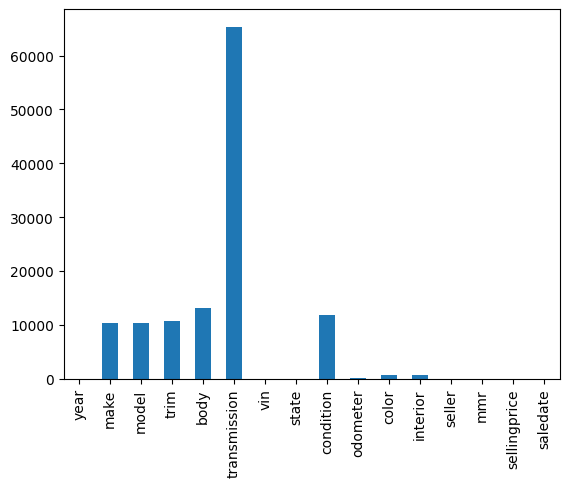

In [31]:
# 1.3 Missing & Anomaly Detection
# Quantify nulls per column; visualize with a bar chart or heatmap.
nulls = cars.isnull().sum()
print(nulls)

cars.isnull().sum().plot(kind='bar')


In [32]:
# Resolve null values by appropriate strategy based on the datatype and percentage of null values.

for col in cars.columns:
    if cars[col].dtype in ['float64', 'int64']:
        cars[col] = cars[col].fillna(cars[col].median())
    else:
        cars[col] = cars[col].fillna(cars[col].mode()[0])

In [33]:
# Count number of duplicate records and delete if any present

duplicates = cars.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")

Number of duplicate records: 0


2. Data frames Queries:

In [34]:
# 2.1 Calculate the average, minimum, and maximum car price?

round(cars['sellingprice'].describe(), 2)

count    558837.00
mean      13611.27
std        9749.41
min           1.00
25%        6900.00
50%       12100.00
75%       18200.00
max      230000.00
Name: sellingprice, dtype: float64

In [35]:
# 2.2 List all unique colors of cars?

cars['color'].unique()

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', 'orange', 'off-white', 'turquoise', 'pink', 'lime'],
      dtype=object)

In [54]:
# 2.3 Find the number of unique car brands and car models?

unique_brands = cars['make'].nunique()
unique_models = cars['model'].nunique()
print(f"Number of unique car brands: {unique_brands}")
print(f"Number of unique car models: {unique_models}")

Number of unique car brands: 96
Number of unique car models: 973


In [55]:
# 2.4 Find all car information having selling prices greater than $165000?

expensive_cars = cars[cars['sellingprice'] > 165000]
print(expensive_cars)

        year           make       model      trim   body transmission  \
125095  2012    Rolls-Royce       Ghost      Base  Sedan    automatic   
344905  2014           Ford      Escape  Titanium    SUV    automatic   
446949  2015  Mercedes-Benz     S-Class   S65 AMG  Sedan    automatic   
538347  2012    Rolls-Royce       Ghost      Base  sedan    automatic   
545523  2013    Rolls-Royce       Ghost      Base  sedan    automatic   
548169  2011        Ferrari  458 Italia      Base  coupe    automatic   
557570  2012    Rolls-Royce       Ghost       EWB  sedan    automatic   

                      vin state  condition  odometer  color interior  \
125095  sca664s58cux50727    fl       45.0   14316.0  black    beige   
344905  1fmcu9j98eua23833    mo       43.0   27802.0  green      tan   
446949  wddug7kb2fa102347    ca       41.0    5277.0  white    white   
538347  sca664s59cux50803    ca       44.0    5215.0  white      tan   
545523  sca664s52dux52152    fl       42.0    7852.0  w

In [56]:
# 2.5 Find the top 5 most frequently sold car models?

top_models = cars['model'].value_counts().head(5)
print(top_models)

model
Altima    29748
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64


In [57]:
# 2.6 What is the average selling price of cars by brand (make)?

average_price_by_brand = cars.groupby('make')['sellingprice'].mean().round(2)
print(average_price_by_brand)

make
Acura           14017.27
Aston Martin    54812.00
Audi            19915.43
BMW             21441.90
Bentley         74367.67
                  ...   
subaru           3710.42
suzuki           4810.00
toyota           7339.11
volkswagen       6145.83
vw              13672.92
Name: sellingprice, Length: 96, dtype: float64


In [58]:
# 2.7 What is the minimum selling price of cars for each interior?

min_price_by_interior = cars.groupby('interior')['sellingprice'].min().round(2)
print(min_price_by_interior)

interior
beige         100.0
black           1.0
blue          150.0
brown         200.0
burgundy      175.0
gold          250.0
gray            1.0
green         100.0
off-white     900.0
orange       1200.0
purple        200.0
red           200.0
silver        150.0
tan           100.0
white         350.0
yellow       3100.0
—             150.0
Name: sellingprice, dtype: float64


In [60]:
# 2.8 Find highest odometer reading per year from highest to lowest order?

odometer_by_year = cars.groupby('year')['odometer'].max().sort_values(ascending=False)
print(odometer_by_year)

year
1997    999999.0
1996    999999.0
2014    999999.0
2013    999999.0
1998    999999.0
1999    999999.0
1993    999999.0
2010    999999.0
2009    999999.0
2012    999999.0
2008    999999.0
2007    999999.0
2005    999999.0
2006    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2011    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0
Name: odometer, dtype: float64


In [62]:
# 2.9 Create a new column for car age (assuming the current year is 2025)

cars['car_age'] = 2026 - cars['year']
print(cars[['year', 'car_age']].head())

   year  car_age
0  2015       11
1  2015       11
2  2014       12
3  2015       11
4  2014       12


In [63]:
# 2.10 Find the number of cars having a condition greater than or equal to 48 and odometer greater than 90000?

condition_odometer_cars = cars[(cars['condition'] >= 48) & (cars['odometer'] > 90000)]
print(condition_odometer_cars.shape[0])

746


In [65]:
# 2.11 Which state consistently has higher car prices for newer cars(year>2013)?

newer_cars = cars[cars['year'] > 2013]
average_price_by_state = newer_cars.groupby('state')['sellingprice'].mean().round(2)
print(average_price_by_state.sort_values(ascending=False))

state
oh    28020.22
ab    25204.26
nj    24237.06
on    22962.56
qc    22722.94
pa    22190.23
tn    21841.68
mi    21411.62
ca    20951.32
wa    20598.72
co    20590.38
fl    20235.68
ne    20005.96
ga    19979.51
il    19960.11
tx    19889.83
nv    19810.15
ny    19730.36
mn    19690.79
mo    19601.37
wi    19266.27
la    19171.54
va    19114.26
az    18846.82
ut    18794.51
ns    18716.67
hi    18063.16
md    17739.03
ma    17709.56
nc    17265.97
sc    16999.65
or    16489.51
ms    16141.25
in    15564.70
pr    15379.86
nm    15214.29
al    14900.00
ok    10600.00
Name: sellingprice, dtype: float64


In [45]:
# 2.12 For cars with excellent condition (top 20%), which makes have the lowest average price (value for money)?

3. Data Visualization and insights:

In [46]:
# 3.1 Show the correlation of all the features(columns) having numerical values(e.g. selling price, odometer).

In [47]:
# 3.2 Plot a graph to show the average selling price by year and explain the pattern you notice from the graph. Which plot will you use bar or scatter?

In [48]:
# 3.3 Plot a graph to show average selling price by odometer and explain the trend you notice from the graph.

In [49]:
# 3.4 Plot a graph to show the number of cars sold in each state. Find the top three highest car selling states by having a look at the graph?

In [50]:
# 3.5 Plot a bar graph of average selling price by condition score ranges of size 5. Give a summary of the insights.

In [51]:
# 3.6 Plot a bar graph of no. of cars sold by condition ranges of size 10. Give some insights from the graph.

In [52]:
# 3.7 Plot a box plot to show the distribution of car selling prices grouped by color. Extract insights and if required, remove outliers and plot the graph again.